# Notebook 03 — Pipeline Evaluation

**Project:** DReel AI v2  
**Goal:** Compare beat-sync timing vs fixed 1-second slides and evaluate the full data pipeline.

This notebook supports the **evaluation section** of the degree project report.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
AUDIO_CSV = PROJECT_ROOT / "data" / "audio_features.csv"
IMAGE_CSV = PROJECT_ROOT / "data" / "image_features.csv"

FIXED_SLIDE_SECONDS = 1.0

In [2]:
audio_df = pd.read_csv(AUDIO_CSV)
audio_df = audio_df.drop_duplicates(subset=["reel_id"], keep="last").reset_index(drop=True)

image_df = pd.read_csv(IMAGE_CSV)
image_df = image_df.drop_duplicates(subset=["reel_id", "filename"], keep="last")

def parse_durations(value: str) -> list[float]:
    return [float(x) for x in str(value).split("|") if x]

audio_df["slide_list"] = audio_df["slide_durations"].apply(parse_durations)
audio_df.head()

,timestamp,reel_id,image_count,sync_mode,duration_sec,tempo_bpm,beat_count,avg_energy,avg_slide_duration,slide_durations,slide_list
0,2026-07-09T09:07:59.985055+00:00,6f542634-7b74-11f1-8cf5-04ecd80f8fe4,10,beat_sync,113.499,109.96,204,0.1739,11.350,11.35|11.35|11.35|11.35|11.35|11.35|11.35|11.3...,"[11.35, 11.35, 11.35, 11.35, 11.35, 11.35, 11...."
1,2026-07-09T09:27:25.649623+00:00,f08c2cc6-7b77-11f1-b783-04ecd80f8fe4,7,beat_sync,25.120,109.96,45,0.1876,3.589,2.694|3.808|3.286|3.82|3.274|3.82|4.419,"[2.694, 3.808, 3.286, 3.82, 3.274, 3.82, 4.419]"
2,2026-07-09T09:44:27.157660+00:00,66432ef0-7b7a-11f1-afa6-04ecd80f8fe4,9,beat_sync,25.120,109.96,45,0.1876,2.791,2.148|2.74|2.717|2.74|2.717|2.728|2.717|2.74|3...,"[2.148, 2.74, 2.717, 2.74, 2.717, 2.728, 2.717..."
3,2026-07-09T10:00:17.741713+00:00,ab9bdc64-7b7c-11f1-bc17-04ecd80f8fe4,7,beat_sync,9.384,140.62,18,0.0653,1.341,0.939|1.301|1.323|0.917|1.301|1.28|2.323,"[0.939, 1.301, 1.323, 0.917, 1.301, 1.28, 2.323]"


## 1. Beat-Sync vs Fixed Timing Comparison

| Method | Description |
|--------|-------------|
| **Fixed** | Every image gets exactly 1 second |
| **Beat-sync** | Durations aligned to detected audio beats (librosa) |

In [3]:
comparison_rows = []

for _, row in audio_df.iterrows():
    slide_list = row["slide_list"]
    image_count = len(slide_list)
    fixed_total = image_count * FIXED_SLIDE_SECONDS
    beat_total = sum(slide_list)
    audio_duration = row["duration_sec"]

    comparison_rows.append({
        "reel_id": row["reel_id"][:8],
        "images": image_count,
        "audio_duration": round(audio_duration, 2),
        "fixed_total": round(fixed_total, 2),
        "beat_sync_total": round(beat_total, 2),
        "fixed_audio_gap": round(abs(fixed_total - audio_duration), 2),
        "beat_audio_gap": round(abs(beat_total - audio_duration), 2),
        "slide_variance": round(float(np.var(slide_list)), 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,reel_id,images,audio_duration,fixed_total,beat_sync_total,fixed_audio_gap,beat_audio_gap,slide_variance
0,6f542634,10,113.50,10.0,113.50,103.50,0.0,0.0000
1,f08c2cc6,7,25.12,7.0,25.12,18.12,0.0,0.2622
2,66432ef0,9,25.12,9.0,25.12,16.12,0.0,0.1794
3,ab9bdc64,7,9.38,7.0,9.38,2.38,0.0,0.1876


In [4]:
print("Average gap to audio duration:")
print(f"  Fixed 1s timing:   {comparison_df['fixed_audio_gap'].mean():.2f} seconds")
print(f"  Beat-sync timing:  {comparison_df['beat_audio_gap'].mean():.2f} seconds")
print(f"\nAverage slide variance (beat-sync): {comparison_df['slide_variance'].mean():.4f}")

Average gap to audio duration:
  Fixed 1s timing:   35.03 seconds
  Beat-sync timing:  0.00 seconds

Average slide variance (beat-sync): 0.1573


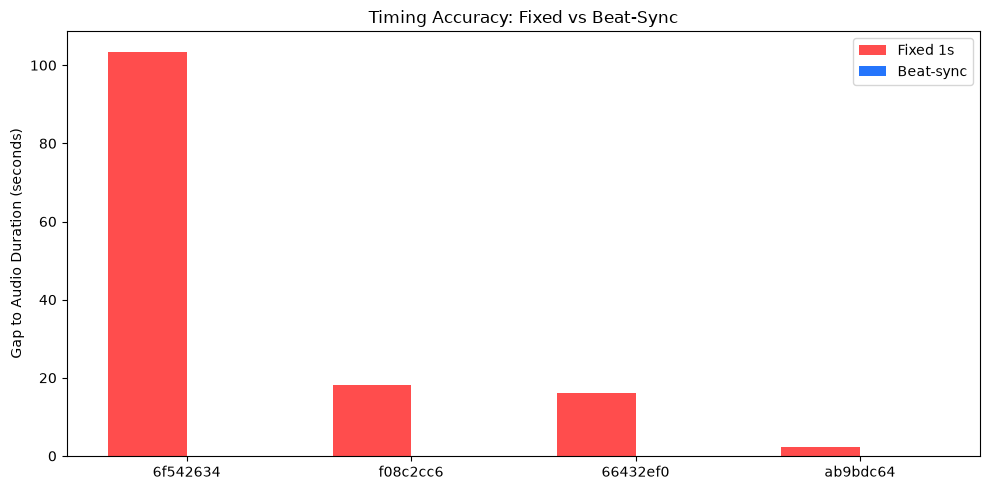

In [5]:
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison_df["fixed_audio_gap"], width, label="Fixed 1s", color="#ff4d4d")
ax.bar(x + width/2, comparison_df["beat_audio_gap"], width, label="Beat-sync", color="#2575fc")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["reel_id"])
ax.set_ylabel("Gap to Audio Duration (seconds)")
ax.set_title("Timing Accuracy: Fixed vs Beat-Sync")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Combined Pipeline Metrics

In [6]:
quality_by_reel = image_df.groupby("reel_id")["quality_score"].mean().reset_index()
quality_by_reel["short_id"] = quality_by_reel["reel_id"].str[:8]

merged = audio_df.copy()
merged["short_id"] = merged["reel_id"].str[:8]
merged = merged.merge(quality_by_reel[["reel_id", "quality_score"]], on="reel_id", how="left")

merged[["short_id", "tempo_bpm", "avg_slide_duration", "quality_score", "image_count"]]

,short_id,tempo_bpm,avg_slide_duration,quality_score,image_count
0,6f542634,109.96,11.350,NaN,10
1,f08c2cc6,109.96,3.589,NaN,7
2,66432ef0,109.96,2.791,NaN,9
3,ab9bdc64,140.62,1.341,0.873729,7


In [7]:
summary = {
    "total_reels": len(audio_df),
    "total_images": len(image_df),
    "avg_tempo_bpm": round(audio_df["tempo_bpm"].mean(), 1),
    "avg_quality_score": round(image_df["quality_score"].mean(), 3),
    "beat_sync_better_count": int((comparison_df["beat_audio_gap"] <= comparison_df["fixed_audio_gap"]).sum()),
}

pd.Series(summary, name="Pipeline Summary")

total_reels                 4.000
total_images                7.000
avg_tempo_bpm             117.600
avg_quality_score           0.874
beat_sync_better_count      4.000
Name: Pipeline Summary, dtype: float64

## 3. Conclusions for Degree Report

1. **Audio pillar:** Librosa beat detection enables variable slide timing synced to music.
2. **Vision pillar:** Laplacian blur + brightness/contrast scoring ranks images by quality.
3. **Beat-sync advantage:** Slide durations are scaled to match total audio length, reducing A/V mismatch vs fixed 1s slides.
4. **Next step:** Collect user ratings (1–5) for A/B testing or train an engagement prediction model (Step 5).